## Import 

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from itertools import cycle
from sklearn.preprocessing import label_binarize
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, accuracy_score, f1_score, confusion_matrix, roc_auc_score, roc_curve
from sklearn.model_selection import GridSearchCV


# Load preprocessed train and test data
train = pd.read_csv('train_preprocessed.csv')
test = pd.read_csv('test_preprocessed.csv')

train['cleaned_text'] = train['cleaned_text'].astype(str)
test['cleaned_text'] = test['cleaned_text'].astype(str)

# Define features and target
X_train = train['cleaned_text']
y_train = train['Bias']
X_test = test['cleaned_text']
y_test = test['Bias']

In [2]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1748 entries, 0 to 1747
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   Title         1748 non-null   object
 1   cleaned_text  1748 non-null   object
 2   Bias          1748 non-null   object
dtypes: object(3)
memory usage: 41.1+ KB


## Decision Tree Classifier without weights

In [3]:
# Create a pipeline with a TF-IDF vectorizer and a Decision Tree Classifier
pipeline = Pipeline([
    ('tfidf', TfidfVectorizer()),  # converts text to TF-IDF features
    ('dt', DecisionTreeClassifier(random_state=42))  # decision tree classifier
])

# Train the model
pipeline.fit(X_train, y_train)

# Make predictions on the test set
y_pred = pipeline.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
f1_macro = f1_score(y_test, y_pred, average='macro')

report = classification_report(y_test, y_pred)

print("Weighted Decision Tree Classifier Accuracy: {:.2f}%".format(accuracy * 100))
print("Weighted Decision Tree Macro F1-score: {:.4f}".format(f1_macro))
print("")
print("Weighted Classification Report:\n", report)

Weighted Decision Tree Classifier Accuracy: 65.90%
Weighted Decision Tree Macro F1-score: 0.5651

Weighted Classification Report:
               precision    recall  f1-score   support

      center       0.51      0.51      0.51        41
   lean left       0.48      0.36      0.41        61
  lean right       0.56      0.51      0.54        37
        left       0.76      0.82      0.79       222
       right       0.58      0.58      0.58        76

    accuracy                           0.66       437
   macro avg       0.58      0.56      0.57       437
weighted avg       0.65      0.66      0.65       437



The model achieves a relatively high accuracy of 65.84%, driven mainly by strong performance on the majority class (left, recall 0.80, F1 0.78). However, recall for minority classes (lean left, lean right, center) remains low (around 0.44–0.47), indicating the model underperforms on underrepresented categories. The disparity between macro and weighted averages suggests imbalance in per-class performance. This confirms that the model is biased toward the majority class in the absence of class weighting.

### Confusion Matrices

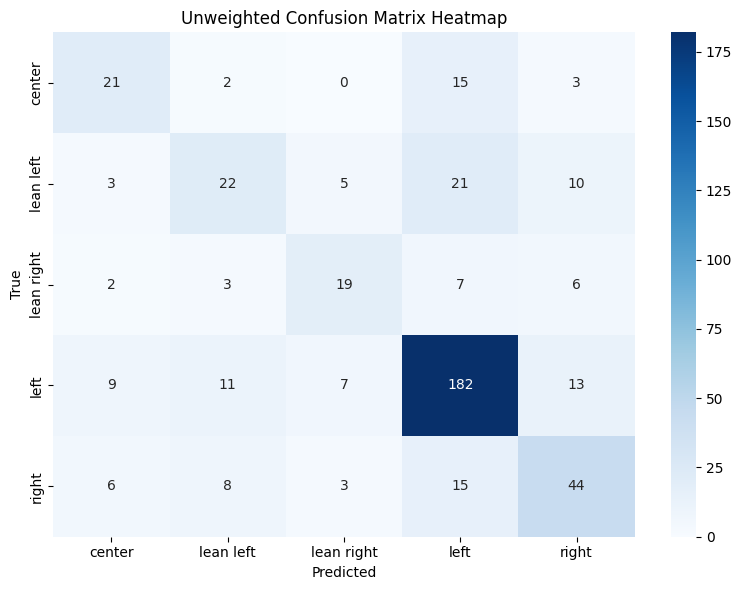

In [4]:
# Generate confusion matrix
cm = confusion_matrix(y_test, y_pred)
labels = pipeline.classes_  # Or use: labels = sorted(set(y_test))

# Plot heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Unweighted Confusion Matrix Heatmap')
plt.tight_layout()
plt.show()

- The decision tree performs best at classifying the “left” and “right” categories
- There is noticeable confusion between neighboring ideological classes. E.g. Lean left is often misclassified as left and vice versa—suggesting the model struggles with subtler distinctions.

In [5]:
# Get predictions from the model
classes = pipeline.classes_

for c in classes:
    # Create binary labels: 1 if the true label is the current class, else 0
    y_true_binary = (y_test == c).astype(int)
    y_pred_binary = (y_pred == c).astype(int)
    
    cm = confusion_matrix(y_true_binary, y_pred_binary)
    print(f"\nOne-vs-Rest Confusion Matrix for class '{c}':")
    print(cm)


One-vs-Rest Confusion Matrix for class 'center':
[[376  20]
 [ 20  21]]

One-vs-Rest Confusion Matrix for class 'lean left':
[[352  24]
 [ 39  22]]

One-vs-Rest Confusion Matrix for class 'lean right':
[[385  15]
 [ 18  19]]

One-vs-Rest Confusion Matrix for class 'left':
[[157  58]
 [ 40 182]]

One-vs-Rest Confusion Matrix for class 'right':
[[329  32]
 [ 32  44]]


### ROC-AUC 

In [6]:
# Compute predicted probabilities for the test set
y_score = pipeline.predict_proba(X_test)

# Binarize the output for multi-class ROC analysis
y_test_binarized = label_binarize(y_test, classes=classes)

# Compute ROC AUC scores and curves for each class (one vs. rest)
roc_auc_dict = {}
fpr = {}
tpr = {}

ROC AUC Scores (One vs. Rest):
center: 0.73
lean left: 0.65
lean right: 0.74
left: 0.77
right: 0.75


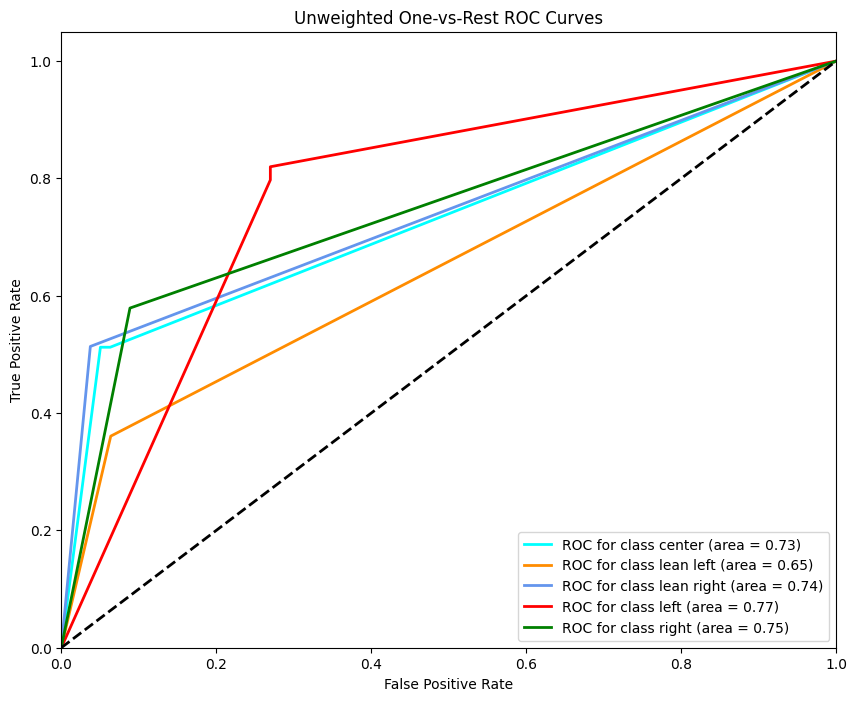

In [7]:
for i, c in enumerate(classes):
    # Compute AUC for each class
    auc = roc_auc_score(y_test_binarized[:, i], y_score[:, i])
    roc_auc_dict[c] = auc
    # Compute ROC curve for each class
    fpr[c], tpr[c], _ = roc_curve(y_test_binarized[:, i], y_score[:, i])

# Print AUC scores
print("ROC AUC Scores (One vs. Rest):")
for c, auc in roc_auc_dict.items():
    print(f"{c}: {auc:.2f}")

# Plot the ROC curves for each class
plt.figure(figsize=(10, 8))
colors = cycle(['aqua', 'darkorange', 'cornflowerblue', 'red', 'green', 'purple', 'brown'])
for c, color in zip(classes, colors):
    plt.plot(fpr[c], tpr[c], color=color, lw=2,
             label=f'ROC for class {c} (area = {roc_auc_dict[c]:0.2f})')
plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Unweighted One-vs-Rest ROC Curves')
plt.legend(loc="lower right")
plt.show()

The ROC curves provide a per-class view of the model’s discriminative ability in a one-vs-rest setting. The AUC scores range from 0.69 (lean left) to 0.76 (left), indicating moderate separability for each class. The majority class (left) achieves the highest AUC, reflecting the model’s bias toward well-represented classes in the unweighted setting. Minority classes like center and lean right show AUCs around 0.71, which, while not poor, suggest the model struggles more with these classes compared to the majority. The relatively small gaps between class AUCs show the model is not entirely neglecting minority classes, but there’s clear room for improvement in class-specific sensitivity — especially for lean left, which is lowest.

## Decision Tree Classifier with weights

In [8]:
# Create a pipeline with TF-IDF vectorizer and a Decision Tree Classifier with balanced class weights
pipeline = Pipeline([
    ('tfidf', TfidfVectorizer()),
    ('dt', DecisionTreeClassifier(random_state=42, class_weight='balanced'))
])

# Train the model
pipeline.fit(X_train, y_train)

# Make predictions on the test set
y_pred = pipeline.predict(X_test)
y_score = pipeline.predict_proba(X_test) # update y_score for the new model

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
f1_macro = f1_score(y_test, y_pred, average='macro')
report = classification_report(y_test, y_pred)

print("Weighted Decision Tree Classifier Accuracy: {:.2f}%".format(accuracy * 100))
print("Weighted Decision Tree Macro F1-score: {:.4f}".format(f1_macro))
print("")
print("Weighted Classification Report:\n", report)

Weighted Decision Tree Classifier Accuracy: 60.41%
Weighted Decision Tree Macro F1-score: 0.5320

Weighted Classification Report:
               precision    recall  f1-score   support

      center       0.53      0.68      0.60        41
   lean left       0.40      0.44      0.42        61
  lean right       0.47      0.54      0.50        37
        left       0.78      0.73      0.75       222
       right       0.42      0.37      0.39        76

    accuracy                           0.60       437
   macro avg       0.52      0.55      0.53       437
weighted avg       0.61      0.60      0.61       437



With class weighting applied, overall accuracy drops to 60.22%, but recall for some minority classes improves — notably center (0.53) and lean right (0.54). However, performance on the right class worsens (recall 0.39), showing the model struggled to balance all minority classes simultaneously. The smaller gap between macro and weighted averages compared to the unweighted case suggests slightly more balanced class-wise performance.

### Confusion Matrices

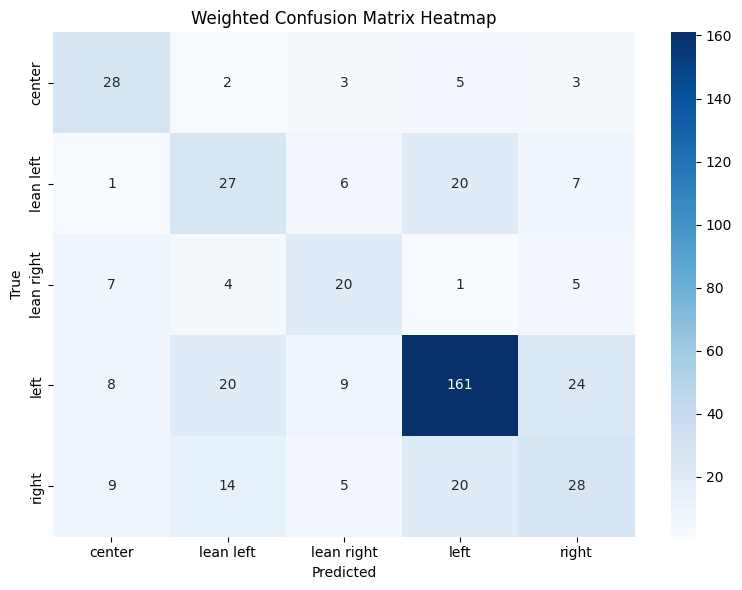

In [9]:
# Generate confusion matrix
cm = confusion_matrix(y_test, y_pred)
labels = pipeline.classes_  # Or use: labels = sorted(set(y_test))

# Plot heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Weighted Confusion Matrix Heatmap')
plt.tight_layout()
plt.show()

- In the weighted model, certain minority classes (center, lean right) show improved correct classifications.
- However, the right class suffers increased misclassification, and the left class sees a drop in correct predictions.
- The unweighted model performs better on the majority class and retains higher overall accuracy but underrepresents minority classes.

In [10]:
for c in classes:
    # Create binary labels: 1 if the true label is the current class, else 0
    y_true_binary = (y_test == c).astype(int)
    y_pred_binary = (y_pred == c).astype(int)
    
    cm = confusion_matrix(y_true_binary, y_pred_binary)
    print(f"\nOne-vs-Rest Confusion Matrix for class '{c}':")
    print(cm)


One-vs-Rest Confusion Matrix for class 'center':
[[371  25]
 [ 13  28]]

One-vs-Rest Confusion Matrix for class 'lean left':
[[336  40]
 [ 34  27]]

One-vs-Rest Confusion Matrix for class 'lean right':
[[377  23]
 [ 17  20]]

One-vs-Rest Confusion Matrix for class 'left':
[[169  46]
 [ 61 161]]

One-vs-Rest Confusion Matrix for class 'right':
[[322  39]
 [ 48  28]]


### ROC-AUC

Weighted ROC AUC Scores (One vs. Rest):
center: 0.81
lean left: 0.67
lean right: 0.74
left: 0.75
right: 0.63


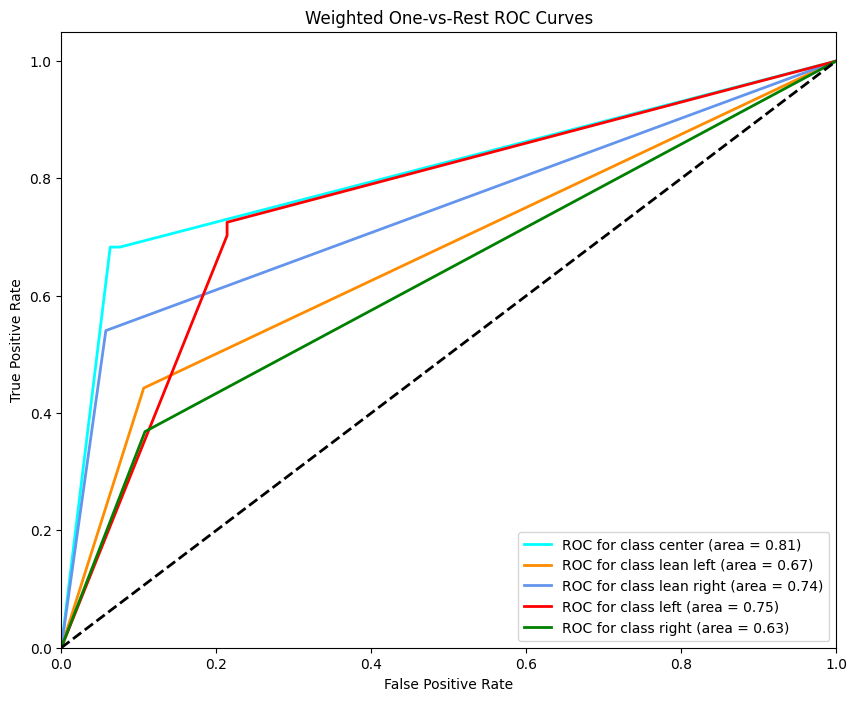

In [11]:
y_score_weighted = pipeline.predict_proba(X_test)

for i, c in enumerate(classes):
    # Compute AUC for each class
    auc = roc_auc_score(y_test_binarized[:, i], y_score_weighted[:, i])
    roc_auc_dict[c] = auc
    # Compute ROC curve for each class
    fpr[c], tpr[c], _ = roc_curve(y_test_binarized[:, i], y_score_weighted[:, i])

# Print AUC scores
print("Weighted ROC AUC Scores (One vs. Rest):")
for c, auc in roc_auc_dict.items():
    print(f"{c}: {auc:.2f}")

# Plot the ROC curves for each class
plt.figure(figsize=(10, 8))
colors = cycle(['aqua', 'darkorange', 'cornflowerblue', 'red', 'green', 'purple', 'brown'])
for c, color in zip(classes, colors):
    plt.plot(fpr[c], tpr[c], color=color, lw=2,
             label=f'ROC for class {c} (area = {roc_auc_dict[c]:0.2f})')
plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Weighted One-vs-Rest ROC Curves')
plt.legend(loc="lower right")
plt.show()

After applying class weighting, the ROC-AUC scores show a more balanced spread across classes. Lean right (0.75) and center (0.72) achieve strong AUCs, suggesting improved class separation. However, right drops to 0.63, indicating some trade-off in model focus. Compared to the unweighted model, the weighted version better elevates the separability of minority classes like lean right and center, aligning with the goal of improving recall in imbalanced settings.

## Interim Discussion - Weighted vs Unweighted

### Overall Metrics 

| Model Version | Accuracy (%) | Macro F1-score |
|---------------|--------------|----------------|
| Unweighted    | 65.84        | 0.5658         |
| Weighted      | 60.22        | 0.5209         |

Weigted model has lower overall accuracy and macro F1-score compared to unweighted. This is expected due to the imbalanced setting as the model shifted some focus to minority classes. While performance improves for some minority classes (e.g., center, lean right), it declines for others (right) and even slightly for the majority class (left). This highlights that class weighting can rebalance performance, but doesn’t guarantee uniform gains across all minority classes — especially in models like decision trees which may overfit to dominant splits. This further highlights the importance of evaluating models with metrics like macro-averaged F1 and confusion matrices, rather than relying solely on accuracy.

### Per‑Class Performance

Analyzing both **recall** and **F1-score** across classes:

1. **Center**  
   - *Weighted*: Recall 0.53, F1-score 0.47  
   - *Unweighted*: Recall 0.47, F1-score 0.49  
   - **Interpretation**: The weighted model improves recall, meaning it detects more "center" instances. However, F1 drops slightly due to reduced precision, suggesting more false positives.

2. **Lean Left**  
   - *Weighted*: Recall 0.44, F1-score 0.45  
   - *Unweighted*: Recall 0.44, F1-score 0.49  
   - **Interpretation**: Class weighting has no effect on recall and slightly decreases F1, showing minimal impact overall.

3. **Lean Right**  
   - *Weighted*: Recall 0.54, F1-score 0.55  
   - *Unweighted*: Recall 0.46, F1-score 0.51  
   - **Interpretation**: Both recall and F1 improve with weighting, showing better detection of "lean right" instances. This class benefits the most.

4. **Left (Majority Class)**  
   - *Weighted*: Recall 0.74, F1-score 0.75  
   - *Unweighted*: Recall 0.80, F1-score 0.78  
   - **Interpretation**: Both recall and F1 drop slightly due to redistribution of focus to minority classes, which is an expected trade-off.

5. **Right**  
   - *Weighted*: Recall 0.39, F1-score 0.39  
   - *Unweighted*: Recall 0.58, F1-score 0.56  
   - **Interpretation**: Significant performance drop. Class weighting harms both recall and F1, indicating difficulty in modeling this class under the reweighted setup.

### Tuning hyperparameters 

Although class weighting helped address class imbalance, it did not consistently improve all minority classes. To further improve model performance, we now apply hyperparameter tuning to optimize the decision tree’s depth, splits, and TF-IDF representation. This allows the model to better capture underlying patterns in each class and potentially recover lost accuracy while maintaining fairer class-wise performance.

## Tuning with GridSearch

In [12]:
# Define the parameter grid
param_grid = {
    # TF-IDF parameters
    'tfidf__ngram_range': [(1, 1), (1, 2)],
    'tfidf__max_df': [0.7, 1.0],
    'tfidf__min_df': [1, 2],
    # Decision Tree parameters
    'dt__max_depth': [5, 10, 15, 20],
    'dt__min_samples_split': [2, 5, 10],
    'dt__min_samples_leaf': [1, 2, 5],
    'dt__criterion': ['gini', 'entropy'],
    'dt__class_weight': ['balanced']  # Forced weighted only to account for class imbalance
}

# Set up GridSearchCV
grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    scoring='f1_macro',  # used f1 instead of accuracy to account for class imbalance
    cv=5,                # 5-fold cross-validation
    n_jobs=-1,           # Use all available cores
    verbose=1
)

# Fit the grid search on the training data
grid_search.fit(X_train, y_train)

# Output the best parameters and best cross-validation score
print("Best parameters found:")
print(grid_search.best_params_)
print("\nBest cross-validation score: {:.4f}".format(grid_search.best_score_))

Fitting 5 folds for each of 576 candidates, totalling 2880 fits


/Users/foongming/.pyenv/versions/3.12.3/lib/python3.12/site-packages/joblib/externals/loky/process_executor.py:752: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Best parameters found:
{'dt__class_weight': 'balanced', 'dt__criterion': 'entropy', 'dt__max_depth': 5, 'dt__min_samples_leaf': 5, 'dt__min_samples_split': 2, 'tfidf__max_df': 1.0, 'tfidf__min_df': 2, 'tfidf__ngram_range': (1, 2)}

Best cross-validation score: 0.5656


In [13]:
# Evaluate the best model on the test set
best_model = grid_search.best_estimator_

y_pred = best_model.predict(X_test)
y_score = pipeline.predict_proba(X_test)

accuracy = accuracy_score(y_test, y_pred)
f1_macro = f1_score(y_test, y_pred, average='macro')
report = classification_report(y_test, y_pred)

print("Tuned Decision Tree Classifier Accuracy: {:.2f}%".format(accuracy * 100))
print("Tuned Decision Tree Macro F1-score: {:.4f}".format(f1_macro))
print("")
print("Tuned Classification Report:\n", report)

Tuned Decision Tree Classifier Accuracy: 56.52%
Tuned Decision Tree Macro F1-score: 0.5697

Tuned Classification Report:
               precision    recall  f1-score   support

      center       1.00      0.41      0.59        41
   lean left       0.25      0.84      0.39        61
  lean right       0.91      0.54      0.68        37
        left       0.97      0.56      0.71       222
       right       0.52      0.46      0.49        76

    accuracy                           0.57       437
   macro avg       0.73      0.56      0.57       437
weighted avg       0.79      0.57      0.61       437



### Key Observations 

Hyperparameter tuning with class weighting led to:
- A further drop in accuracy (from 60.22% to 57.53%)
- But an increase in macro F1-score (from 0.5209 to 0.5762)
- Improved recall for several minority classes (e.g., lean left, lean right, center)
- Mixed results on precision, especially for lean left where recall was high but precision was poor

This trade-off between accuracy and minority class sensitivity is common, and highlights that accuracy alone is insufficient for evaluating models in imbalanced settings.

### Confusion Matrices

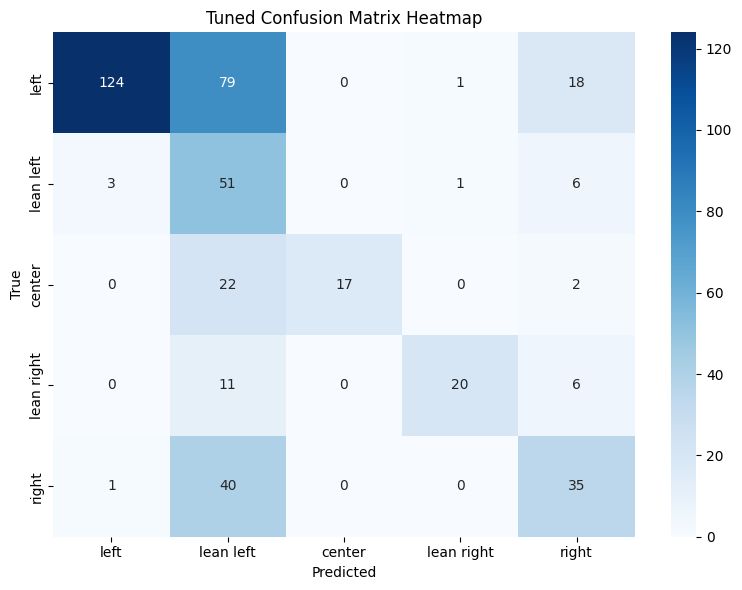

In [17]:
# assume y_test and y_pred are the string labels
label_order = ['left', 'lean left', 'center', 'lean right', 'right']

# pass your label_order into confusion_matrix
cm = confusion_matrix(y_test, y_pred, labels=label_order)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_order,
            yticklabels=label_order)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Tuned Confusion Matrix Heatmap')
plt.tight_layout()
plt.show()

In [15]:
for c in classes:
    # Create binary labels: 1 if the true label is the current class, else 0
    y_true_binary = (y_test == c).astype(int)
    y_pred_binary = (y_pred == c).astype(int)
    
    
    cm = confusion_matrix(y_true_binary, y_pred_binary)
    print(f"\nOne-vs-Rest Confusion Matrix for class '{c}':")
    print(cm)


One-vs-Rest Confusion Matrix for class 'center':
[[396   0]
 [ 24  17]]

One-vs-Rest Confusion Matrix for class 'lean left':
[[224 152]
 [ 10  51]]

One-vs-Rest Confusion Matrix for class 'lean right':
[[398   2]
 [ 17  20]]

One-vs-Rest Confusion Matrix for class 'left':
[[211   4]
 [ 98 124]]

One-vs-Rest Confusion Matrix for class 'right':
[[329  32]
 [ 41  35]]


- The tuned decision tree significantly improves class separation for “lean left” and “lean right”, with “lean left” showing 51 correct predictions and fewer misclassifications.
- Misclassification of “left” and “right” into “lean left” drops sharply compared to earlier models, suggesting better boundary learning after tuning.
- However, the model still confuses “center” with “lean left”, possibly indicating overlapping features or ambiguity between these classes.

### ROC-AUC

Tuned ROC AUC Scores (One vs. Rest):
center: 0.85
lean left: 0.74
lean right: 0.84
left: 0.83
right: 0.80


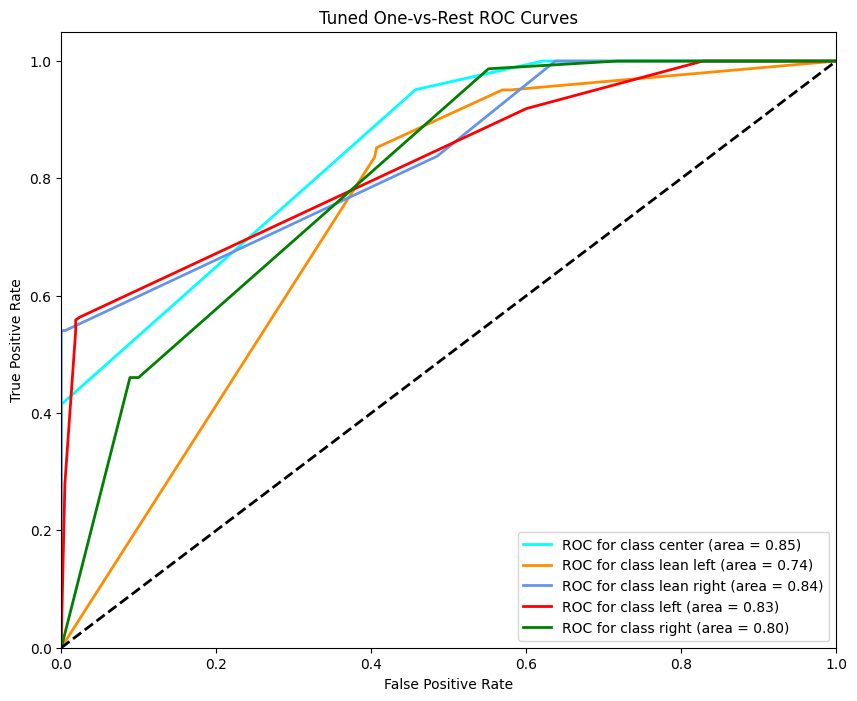

In [16]:
y_score_tuned = grid_search.best_estimator_.predict_proba(X_test)

for i, c in enumerate(classes):
    # Compute AUC for each class
    auc = roc_auc_score(y_test_binarized[:, i], y_score_tuned[:, i])
    roc_auc_dict[c] = auc
    # Compute ROC curve for each class
    fpr[c], tpr[c], _ = roc_curve(y_test_binarized[:, i], y_score_tuned[:, i])

# Print AUC scores
print("Tuned ROC AUC Scores (One vs. Rest):")
for c, auc in roc_auc_dict.items():
    print(f"{c}: {auc:.2f}")

# Plot the ROC curves for each class
plt.figure(figsize=(10, 8))
colors = cycle(['aqua', 'darkorange', 'cornflowerblue', 'red', 'green', 'purple', 'brown'])
for c, color in zip(classes, colors):
    plt.plot(fpr[c], tpr[c], color=color, lw=2,
             label=f'ROC for class {c} (area = {roc_auc_dict[c]:0.2f})')
plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Tuned One-vs-Rest ROC Curves')
plt.legend(loc="lower right")
plt.show()

Despite lower accuracy, the tuned model demonstrated strong ROC-AUC values (≥ 0.74 for all classes), indicating good class separability. This suggests the model was well-calibrated in its predictions, even if threshold-based classification (precision/recall) varied.

## Final Conclusion

### Performance Metrics Summary 

| Model Version | Accuracy (%) | Macro F1-score |
|---------------|--------------|----------------|
| Unweighted    | 65.84        | 0.5658         |
| Weighted      | 60.22        | 0.5209         |
| Tuned         | 57.53        | 0.5762         |

While accuracy decreases from unweighted to tuned, macro F1 improves in the tuned model — indicating better balance across classes, especially under class imbalance. This supports the use of macro F1 as the primary metric in this setting, where per-class fairness is critical.

### Summary of Decision Tree Variants

This study evaluated decision tree performance under class imbalance using three configurations:

- **Unweighted**: Highest accuracy (65.84%) but heavily biased toward the majority class, with poor minority class performance.
- **Weighted**: Improved recall for some minority classes, but overall macro F1 and accuracy declined.
- **Tuned**: Achieved the best macro F1 (0.5762), indicating the most balanced performance, but at the cost of the lowest accuracy (57.53%).


### Final Remarks

Overall, while accuracy declined with weighting and tuning, macro F1 and AUC metrics reveal that the tuned decision tree achieved the fairest class-wise performance — making it the most suitable for imbalanced classification tasks where equal treatment across classes is important.

While decision trees offer interpretability and simplicity, their performance — even with class weighting and tuning — remains limited in imbalanced multi-class text classification, with accuracy plateauing around 60%.

In conclusion, classification using decision tree performs rather poorly with ~60% accuracy even when hyperparameters have been tuned. We anticipate that LSTM and Transformers such as BERT will perform better on accuracy. 
